# 05 — Espacio semántico

Este notebook resume M6. Reutiliza el reporte generado en Khipu y no vuelve a ejecutar PCA, UMAP ni FAISS.

La pregunta es: **¿los embeddings BGE están listos para buscar vecinos y comparar métodos de clustering?**

## 1. Cargar el reporte

In [1]:
import json
from pathlib import Path

import pandas as pd
import yaml
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

report_path = PROJECT_ROOT / 'reports/modeling/semantic_space_results.json'
report = json.loads(report_path.read_text(encoding='utf-8'))
print(f'Reporte: {report_path.relative_to(PROJECT_ROOT)}')
print(f"Fuente DVC: {report['source']['dvc_hash']}")
print(f"Tiempo total: {report['resources']['elapsed_seconds'] / 60:.2f} minutos")

Reporte: reports/modeling/semantic_space_results.json
Fuente DVC: 009e3b35e25d9df095cf753e0a05f041.dir
Tiempo total: 4.23 minutos


## 2. PCA reduce dimensiones

PCA reduce el embedding de 1,024 dimensiones conservando la mayor cantidad posible de variación. La **variación conservada** indica cuánta información estadística permanece después de reducir dimensiones.

,Componentes,Variación conservada
0,32,58.09%
1,64,70.95%
2,128,82.86%
3,256,92.42%


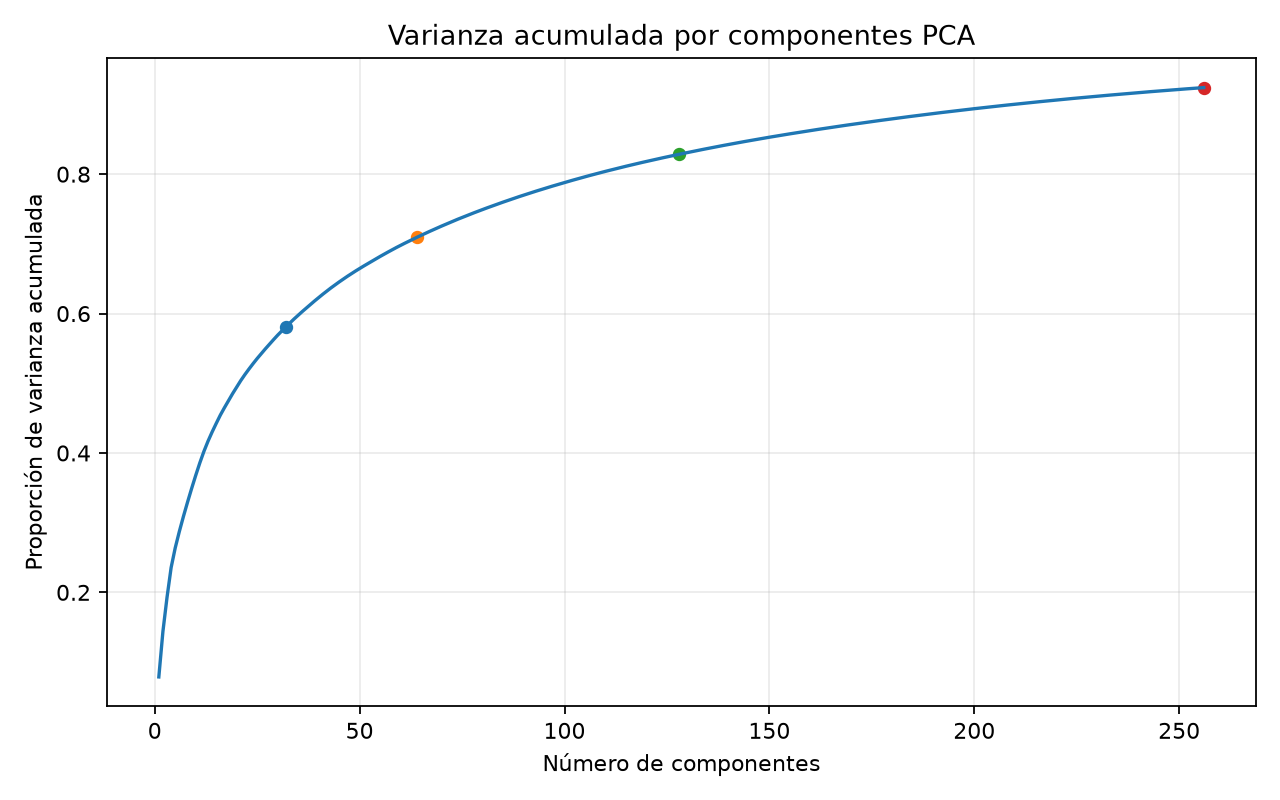

In [2]:
pca_table = pd.DataFrame([
    {
        'Componentes': int(components),
        'Variación conservada': variance,
    }
    for components, variance in report['pca']['variance_checkpoints'].items()
])
pca_table['Variación conservada'] = (
    pca_table['Variación conservada'] * 100
).round(2).astype(str) + '%'
display(pca_table)
display(Image(filename=str(PROJECT_ROOT / 'reports/modeling/semantic_pca_variance.png')))

Con 256 componentes se conserva 92.42% de la variación. Esta será la representación común inicial para comparar clustering en M7.

## 3. UMAP permite inspeccionar el espacio

UMAP proyecta los embeddings en dos dimensiones. Sirve para visualizar solapamientos, zonas densas y casos aislados, pero no demuestra por sí solo que exista un cluster.

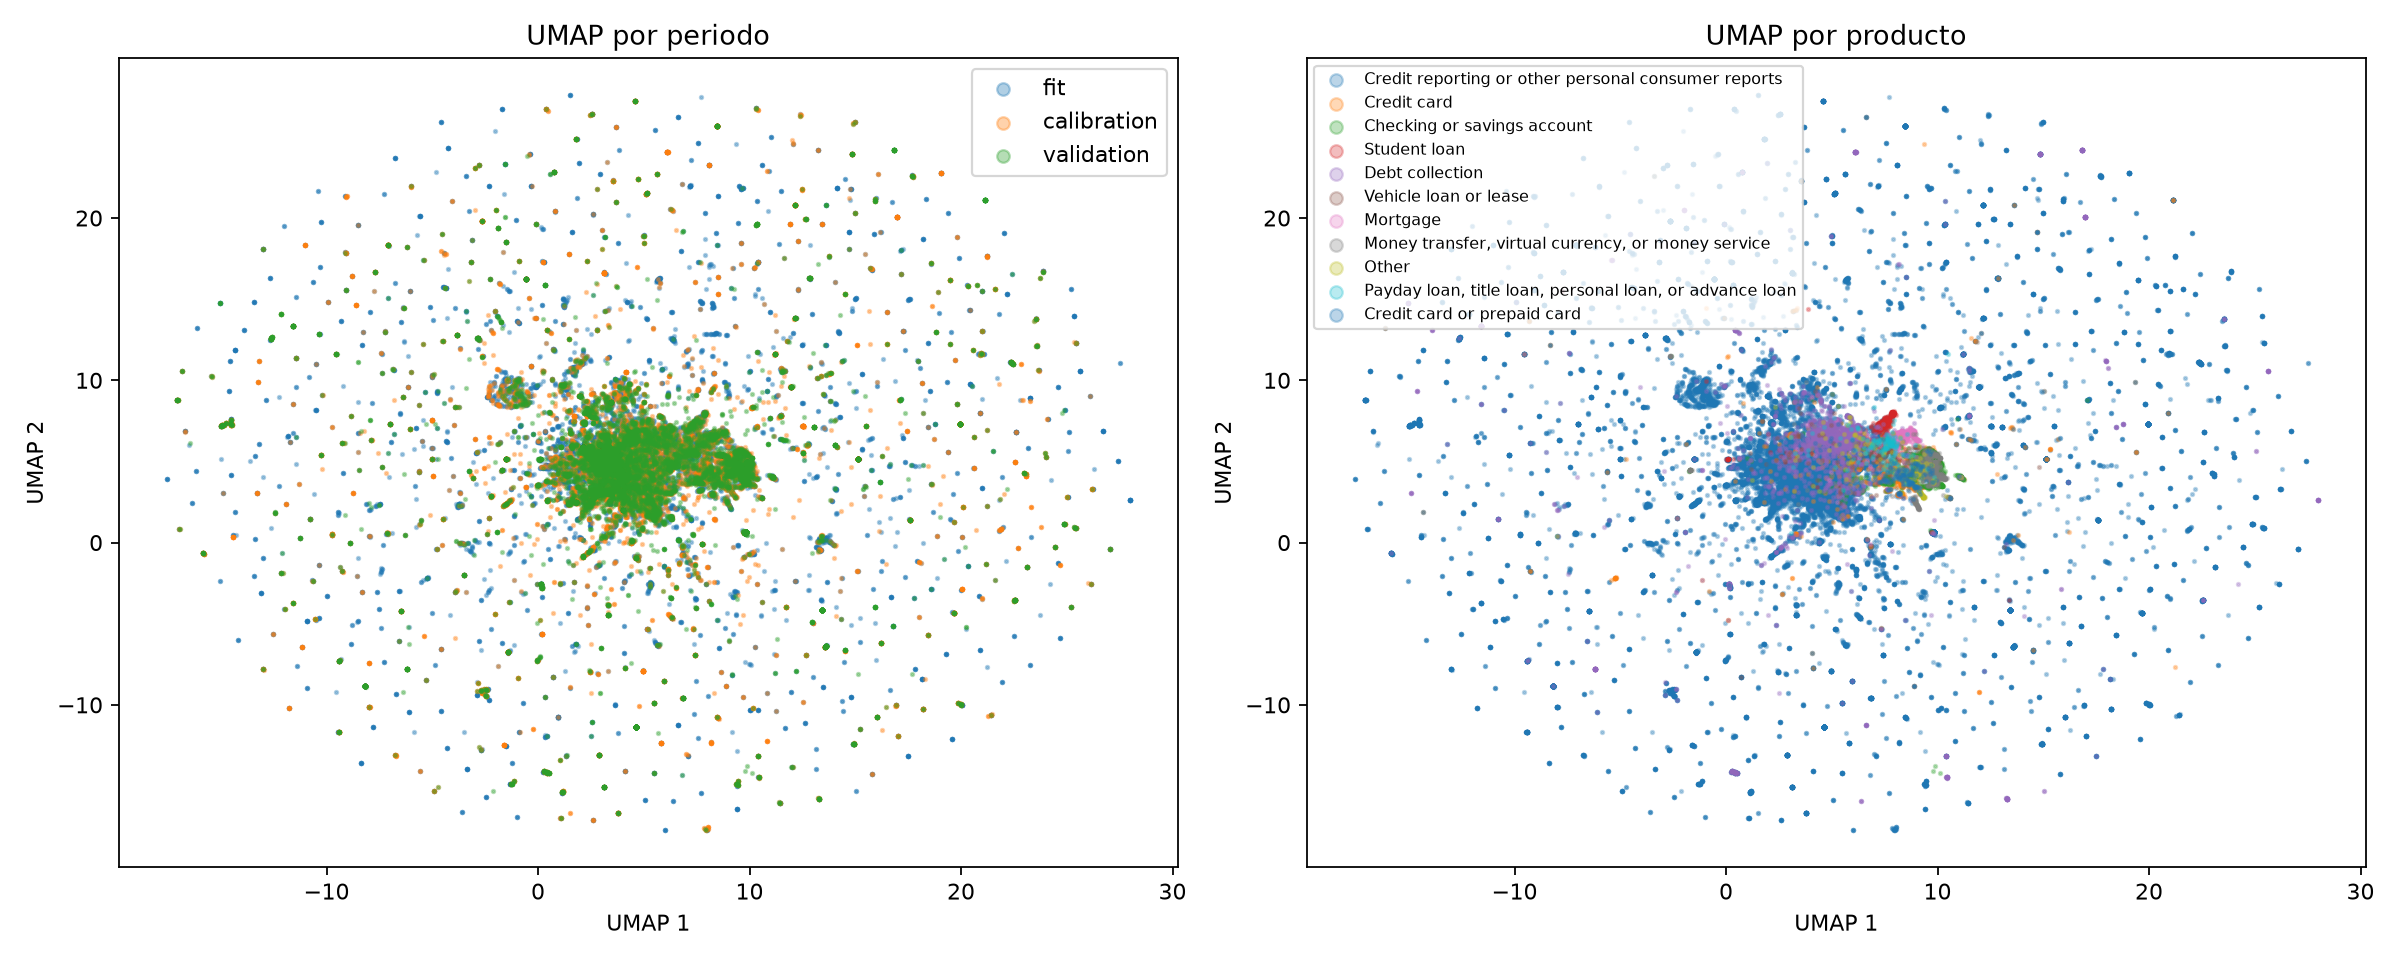

In [3]:
display(Image(filename=str(PROJECT_ROOT / 'reports/modeling/semantic_umap_2d.png')))

Los tres periodos se superponen ampliamente. No se observa una separación temporal total. Los productos muestran zonas diferentes, pero también bastante solapamiento. Por eso M7 necesita comparar clustering y no puede usar solamente este gráfico.

## 4. FAISS recupera vecinos históricos

FAISS buscó el reclamo de ajuste más cercano para 1,000 consultas sin texto compartido de calibración y 1,000 de validación. Una similitud cercana a 1 indica embeddings muy próximos.

In [4]:
neighbor_rows = []
for split, values in report['faiss']['metrics'].items():
    neighbor_rows.append({
        'Periodo': split,
        'Consultas': int(values['queries']),
        'Similitud mediana': values['top1_similarity_median'],
        'Percentil 5': values['top1_similarity_p05'],
        'Mismo producto': values['top1_same_product_rate'],
        'Mismo T1': values['top1_same_t1_rate'],
        'Error contra cálculo directo': values['exact_score_maximum_error'],
    })

neighbor_table = pd.DataFrame(neighbor_rows)
display(neighbor_table.round(4))

,Periodo,Consultas,Similitud mediana,Percentil 5,Mismo producto,Mismo T1,Error contra cálculo directo
0,calibration,1000,0.9245,0.8447,0.827,0.477,0.0
1,validation,1000,0.9177,0.8386,0.771,0.374,0.0


Los vecinos son cercanos y FAISS coincide exactamente con el cálculo directo. Sin embargo, en validación solo 37.4% del vecino más cercano comparte T1. Por tanto, el vecino sirve como evidencia semántica, no como clasificador automático.

## 5. Artefacto reproducible

In [5]:
dvc_path = PROJECT_ROOT / 'artifacts/models/semantic_space.dvc'
dvc_output = yaml.safe_load(dvc_path.read_text(encoding='utf-8'))['outs'][0]
artifact = pd.Series({
    'Ruta': 'artifacts/models/semantic_space',
    'Hash DVC': dvc_output['md5'],
    'Tamaño en bytes': dvc_output['size'],
    'Archivos': dvc_output['nfiles'],
    'FAISS': report['versions']['faiss_cpu'],
    'UMAP': report['versions']['umap_learn'],
})
display(artifact.to_frame('Valor'))

,Valor
Ruta,artifacts/models/semantic_space
Hash DVC,08662a82971a71666b06c9ccf8120d7f.dir
Tamaño en bytes,741782513
Archivos,12
FAISS,1.15.1
UMAP,0.5.12


## 6. Decisión

M6 queda aprobado para continuar a M7:

- PCA conserva suficiente variación con 256 componentes.
- UMAP queda reservado para visualización.
- FAISS queda disponible para vecinos y novedad.
- El vecino más cercano no reemplaza las predicciones T1–T4.
- M7 comparará MiniBatchKMeans++, HDBSCAN y CURE sobre la misma representación.

El run está disponible en [MLflow](https://dagshub.com/WinzCode/capstone-claims-triage.mlflow/#/experiments/0/runs/47bacfc5aa80410ba11020d8701d4f7b).